This module demonstrates the basic steps necessary to download raw gene expression data generated using Affymetrix microarrays from the Gene Expression Omnibus (GEO) public repository, preprocess the data, perform differential expression analysis, and generate plots to visualize the results. The module assumes that R has been already installed.

In [1]:
rm(list=ls())
# Install package BiocManager which enables installing Bioconductor packages if it has not been already installed
if (!requireNamespace("BiocManager", quietly = TRUE)) install.packages("BiocManager")

In [2]:
# Install package GEOquery to download data from Gene Expression Omnibus (GEO) repository
if (!requireNamespace("GEOquery", quietly = TRUE)) BiocManager::install("GEOquery")

Setting options('download.file.method.GEOquery'='auto')

Setting options('GEOquery.inmemory.gpl'=FALSE)



In [3]:
library(GEOquery)
# GEO series GSE15641 has 32 clear cell renal cell carcinoma kidney tumor samples 
# and 23 normal kidney samples. Additional samples are available but will not be used. 

# Download preprocessed data which contains needed sample labels
gse <- getGEO(GEO="GSE15641", destdir=getwd())

Loading required package: Biobase

Loading required package: BiocGenerics


Attaching package: 'BiocGenerics'


The following objects are masked from 'package:stats':

    IQR, mad, sd, var, xtabs


The following objects are masked from 'package:base':

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, intersect, is.unsorted, lapply, Map, mapply,
    match, mget, order, paste, pmax, pmax.int, pmin, pmin.int,
    Position, rank, rbind, Reduce, rownames, sapply, saveRDS, setdiff,
    table, tapply, union, unique, unsplit, which.max, which.min


Welcome to Bioconductor

    Vignettes contain introductory material; view with
    'browseVignettes()'. To cite Bioconductor, see
    'citation("Biobase")', and for packages 'citation("pkgname")'.


Found 1 file(s)

GSE15641_series_matrix.txt.gz



In [4]:
# Build phenotypic data table from extracted sample labels
tab <- pData(gse[[1]])[, c("title","geo_accession")]
head(tab)
labels <- tab[,"title"]
names(labels) <- tab[,"geo_accession"]

,title,geo_accession
,<chr>,<chr>
GSM391107,"normal kidney sample, biological rep1",GSM391107
GSM391108,"normal kidney sample, biological rep2",GSM391108
GSM391109,"normal kidney sample, biological rep3",GSM391109
GSM391110,"normal kidney sample, biological rep4",GSM391110
GSM391111,"normal kidney sample, biological rep5",GSM391111
GSM391112,"normal kidney sample, biological rep6",GSM391112


In [5]:
# Extract the part of labels before the keyword " kidney "
ss <- strsplit(x=labels, split=" kidney ", fixed=TRUE)
class.labels <- unlist(lapply(ss, FUN=function(x){return(x[1])}))

In [6]:
# Remove spaces in labels
class.labels <- gsub(class.labels, pattern=" ", replacement="")

In [7]:
# Create a dataframe of phenotypic data, including group labels and file names
df <- data.frame("Name"=names(class.labels), 
"FileName"=paste(names(class.labels), ".CEL", sep=""), "Target"=class.labels)
head(df)

,Name,FileName,Target
,<chr>,<chr>,<chr>
GSM391107,GSM391107,GSM391107.CEL,normal
GSM391108,GSM391108,GSM391108.CEL,normal
GSM391109,GSM391109,GSM391109.CEL,normal
GSM391110,GSM391110,GSM391110.CEL,normal
GSM391111,GSM391111,GSM391111.CEL,normal
GSM391112,GSM391112,GSM391112.CEL,normal


In [8]:
# Download raw files as a compressed folder under a created folder carrying the name of the GEO series
filePaths <- getGEOSuppFiles("GSE15641")

In [9]:
# Set the working directory to the newly created folder where downloaded data is saved
setwd(paste(getwd(), "/GSE15641", sep=""))

In [10]:
# Decompress the download tar folder GSE15641_RAW.tar
untar("GSE15641_RAW.tar")

In [11]:
# Processing steps for raw files
# Delete the compressed files since no longer needed
file.remove(c("GSE15641_RAW.tar", "GSE15641_mas5_data.txt.gz"))
# find all raw (.CEL) files in the current working directory
fns <- list.files(path=getwd(), pattern=".CEL", full.names=TRUE)
# function gunzip from package R.utils will be needed to unzip files
if (!requireNamespace("R.utils", quietly = TRUE)) BiocManager::install("R.utils")
library(R.utils)
# unzip CEL files without keeping the original zipped files
sapply(fns, gunzip, remove=TRUE)

[1] TRUE TRUE

Warning message:
"package 'R.utils' was built under R version 4.4.3"
Loading required package: R.oo

Loading required package: R.methodsS3

R.methodsS3 v1.8.2 (2022-06-13 22:00:14 UTC) successfully loaded. See ?R.methodsS3 for help.

R.oo v1.27.0 (2024-11-01 18:00:02 UTC) successfully loaded. See ?R.oo for help.


Attaching package: 'R.oo'


The following object is masked from 'package:R.methodsS3':

    throw


The following objects are masked from 'package:methods':

    getClasses, getMethods


The following objects are masked from 'package:base':

    attach, detach, load, save


R.utils v2.13.0 (2025-02-24 21:20:02 UTC) successfully loaded. See ?R.utils for help.


Attaching package: 'R.utils'


The following object is masked from 'package:utils':

    timestamp


The following objects are masked from 'package:base':

    cat, commandArgs, getOption, isOpen, nullfile, parse, use, warnings




C:/Users/rahmatallahyasir/Desktop/Yasir/anaconda/GSE15641/GSM391107.CEL.gz 
 "C:/Users/rahmatallahyasir/Desktop/Yasir/anaconda/GSE15641/GSM391107.CEL" 
C:/Users/rahmatallahyasir/Desktop/Yasir/anaconda/GSE15641/GSM391108.CEL.gz 
 "C:/Users/rahmatallahyasir/Desktop/Yasir/anaconda/GSE15641/GSM391108.CEL" 
C:/Users/rahmatallahyasir/Desktop/Yasir/anaconda/GSE15641/GSM391109.CEL.gz 
 "C:/Users/rahmatallahyasir/Desktop/Yasir/anaconda/GSE15641/GSM391109.CEL" 
C:/Users/rahmatallahyasir/Desktop/Yasir/anaconda/GSE15641/GSM391110.CEL.gz 
 "C:/Users/rahmatallahyasir/Desktop/Yasir/anaconda/GSE15641/GSM391110.CEL" 
C:/Users/rahmatallahyasir/Desktop/Yasir/anaconda/GSE15641/GSM391111.CEL.gz 
 "C:/Users/rahmatallahyasir/Desktop/Yasir/anaconda/GSE15641/GSM391111.CEL" 
C:/Users/rahmatallahyasir/Desktop/Yasir/anaconda/GSE15641/GSM391112.CEL.gz 
 "C:/Users/rahmatallahyasir/Desktop/Yasir/anaconda/GSE15641/GSM391112.CEL" 
C:/Users/rahmatallahyasir/Desktop/Yasir/anaconda/GSE15641/GSM391113.CEL.gz 
 "C:/Users/rahmatallahyasir/Desktop/Yasir/anaconda/GSE15641/GSM391113.CEL" 
C:/Users/rahmatallahyasir/Desktop/Yasir/anaconda/GSE15641/GSM391114.CEL.gz 
 "C:/Users/rahmatallahyasir/Desktop/Yasir/anaconda/GSE15641/GSM391114.CEL" 
C:/Users/rahmatallahyasir/Desktop/Yasir/anaconda/GSE15641/GSM391115.CEL.gz 
 "C:/Users/rahmatallahyasir/Desktop/Yasir/anaconda/GSE15641/GSM391115.CEL" 
C:/Users/rahmatallahyasir/Desktop/Yasir/anaconda/GSE15641/GSM391116.CEL.gz 
 "C:/Users/rahmatallahyasir/Desktop/Yasir/anaconda/GSE15641/GSM391116.CEL" 
C:/Users/rahmatallahyasir/Desktop/Yasir/anaconda/GSE15641/GSM391117.CEL.gz 
 "C:/Users/rahmatallahyasir/Desktop/Yasir/anaconda/GSE15641/GSM391117.CEL" 
C:/Users/rahmatallahyasir/Desktop/Yasir/anaconda/GSE15641/GSM391118.CEL.gz 
 "C:/Users/rahmatallahyasir/Desktop/Yasir/anaconda/GSE15641/GSM391118.CEL" 
C:/Users/rahmatallahyasir/Desktop/Yasir/anaconda/GSE15641/GSM391119.CEL.gz 
 "C:/Users/rahmatallahyasir/Desktop/Yasir/anaconda/GSE15641/GSM391119.CEL" 
C:/Users/rahmatallahyasir/Desktop/Yasir/anaconda/GSE15641/GSM391120.CEL.gz 
 "C:/Users/rahmatallahyasir/Desktop/Yasir/anaconda/GSE15641/GSM391120.CEL" 
C:/Users/rahmatallahyasir/Desktop/Yasir/anaconda/GSE15641/GSM391121.CEL.gz 
 "C:/Users/rahmatallahyasir/Desktop/Yasir/anaconda/GSE15641/GSM391121.CEL" 
C:/Users/rahmatallahyasir/Desktop/Yasir/anaconda/GSE15641/GSM391122.CEL.gz 
 "C:/Users/rahmatallahyasir/Desktop/Yasir/anaconda/GSE15641/GSM391122.CEL" 
C:/Users/rahmatallahyasir/Desktop/Yasir/anaconda/GSE15641/GSM391123.CEL.gz 
 "C:/Users/rahmatallahyasir/Desktop/Yasir/anaconda/GSE15641/GSM391123.CEL" 
C:/Users/rahmatallahyasir/Desktop/Yasir/anaconda/GSE15641/GSM391124.CEL.gz 
 "C:/Users/rahmatallahyasir/Desktop/Yasir/anaconda/GSE15641/GSM391124.CEL" 
C:/Users/rahmatallahyasir/Desktop/Yasir/anaconda/GSE15641/GSM391125.CEL.gz 
 "C:/Users/rahmatallahyasir/Desktop/Yasir/anaconda/GSE15641/GSM391125.CEL" 
C:/Users/rahmatallahyasir/Desktop/Yasir/anaconda/GSE15641/GSM391126.CEL.gz 
 "C:/Users/rahmatallahyasir/Desktop/Yasir/anaconda/GSE15641/GSM391126.CEL" 
C:/Users/rahmatallahyasir/Desktop/Yasir/anaconda/GSE15641/GSM391127.CEL.gz 
 "C:/Users/rahmatallahyasir/Desktop/Yasir/anaconda/GSE15641/GSM391127.CEL" 
C:/Users/rahmatallahyasir/Desktop/Yasir/anaconda/GSE15641/GSM391128.CEL.gz 
 "C:/Users/rahmatallahyasir/Desktop/Yasir/anaconda/GSE15641/GSM391128.CEL" 
C:/Users/rahmatallahyasir/Desktop/Yasir/anaconda/GSE15641/GSM391129.CEL.gz 
 "C:/Users/rahmatallahyasir/Desktop/Yasir/anaconda/GSE15641/GSM391129.CEL" 
C:/Users/rahmatallahyasir/Desktop/Yasir/anaconda/GSE15641/GSM391130.CEL.gz 
 "C:/Users/rahmatallahyasir/Desktop/Yasir/anaconda/GSE15641/GSM391130.CEL" 
C:/Users/rahmatallahyasir/Desktop/Yasir/anaconda/GSE15641/GSM391131.CEL.gz 
 "C:/Users/rahmatallahyasir/Desktop/Yasir/anaconda/GSE15641/GSM391131.CEL" 
C:/Users/rahmatallahyasir/Desktop/Yasir/anaconda/GSE15641/GSM391132.CEL.gz 
 "C:/Users/rahmatallahyasir/Desktop/Yasir/anaconda/GSE15641/GSM391132.CEL" 
C:/Users/rahmatallahyasir/Desktop/Yasir/anaconda

In [12]:
# Read raw files into one ExpressionSet object using package affy
# install package affy if it has not been already installed
if (!requireNamespace("affy", quietly = TRUE)) BiocManager::install("affy")
library(affy)

In [13]:
# Read the phenotypic data table into an annotated data table object
adf <- AnnotatedDataFrame(df)

In [14]:
# Get group labels
pd <- pData(adf)$Target
# Get the indices of only two groups: normal and clear cell renal cell carcinoma
ind <- which((pd == "normal") | (pd == "clearcellRCC"))
adf <- adf[ind]

In [15]:
# Get CEL file names that match file names in the annotated dataframe
cels <- list.files(pattern=".CEL")
cels <- intersect(cels, pData(adf)$FileName)

In [16]:
# Read CEL files and phenotypic data into one affybatch object
# Package will be needed. You can install the package or let it be installed automatically by command ReadAffy
library(hgu133acdf)
mybatch <- ReadAffy(filenames=cels, phenoData=adf)
mybatch

Warning message:
"replacing previous import 'AnnotationDbi::head' by 'utils::head' when loading 'hgu133acdf'"
Warning message:
"replacing previous import 'AnnotationDbi::tail' by 'utils::tail' when loading 'hgu133acdf'"




AffyBatch object
size of arrays=712x712 features (43 kb)
cdf=HG-U133A (22283 affyids)
number of samples=55
number of genes=22283
annotation=hgu133a
notes=

In [17]:
# Perform quality assessment using Normalized Unscaled Standard Error (NUSE)
# Install package affyPLM if it has not been already installed
if (!requireNamespace("affyPLM", quietly = TRUE)) BiocManager::install("affyPLM")
library(affyPLM)
dataPLM <- fitPLM(mybatch)

Loading required package: gcrma

Loading required package: preprocessCore



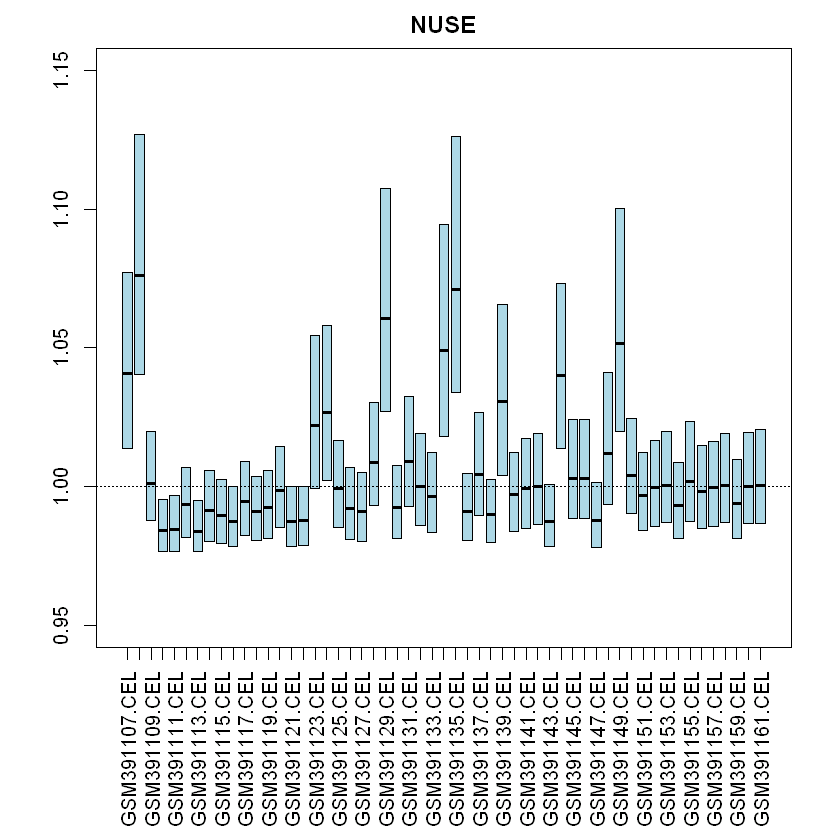

In [18]:
# Generate boxplots of calculated NUSE for samples
par(mfcol=c(1,1), mar=c(8,4,2,2)) # create 2-by-1 plotting panels
aa <- boxplot(dataPLM, main="NUSE", ylim=c(0.95, 1.15), outline=FALSE,
col="lightblue", las=3, whisklty=0, staplelty=0)
abline(h=1, lty=3)

In [19]:
# Identify poor quality samples as those deviating from the majority of the dataset
# We deem samples with median NUSE >1.02 as poor quality samples
badSamples.index <- which(aa$stats[3,] > 1.02)
# bad samples consist of 5 normal and 5 clearcellRCC samples
mybatch$Target[badSamples.index]

[1] "normal"       "normal"       "normal"       "normal"       "normal"      
 [6] "clearcellRCC" "clearcellRCC" "clearcellRCC" "clearcellRCC" "clearcellRCC"

In [20]:
# Discard samples deemed of poor quality
mybatch.filtered <- mybatch[, -badSamples.index]

In [21]:
# Perform preprocessing steps: Background correction, normalization, and summarization
# using the Robust Multi-Array (RMA) method. The output is an ExpressionSet object
eSet <- rma(mybatch.filtered, background=TRUE, normalize=TRUE)
eSet

Background correcting
Normalizing
Calculating Expression


ExpressionSet (storageMode: lockedEnvironment)
assayData: 22283 features, 45 samples 
  element names: exprs 
protocolData
  sampleNames: GSM391109.CEL GSM391110.CEL ... GSM391161.CEL (45 total)
  varLabels: ScanDate
  varMetadata: labelDescription
phenoData
  sampleNames: GSM391109.CEL GSM391110.CEL ... GSM391161.CEL (45 total)
  varLabels: Name FileName Target
  varMetadata: labelDescription
featureData: none
experimentData: use 'experimentData(object)'
Annotation: hgu133a 

In [22]:
# Use package genefilter to summarize intensities from probes mapping to the same gene
# Install package genefilter if it has not been already installed
if (!requireNamespace("genefilter", quietly = TRUE)) BiocManager::install("genefilter")
# Install the annotation package for the Affynetrix chip if it has not been already installed
if (!requireNamespace("hgu133a.db", quietly = TRUE)) BiocManager::install("hgu133a.db")
# Install package org.Hs.eg.db if it has not been already installed (needed to map between identifiers)
if (!requireNamespace("org.Hs.eg.db", quietly = TRUE)) BiocManager::install("org.Hs.eg.db")
library(genefilter)
library(hgu133a.db)
library(org.Hs.eg.db)





Loading required package: AnnotationDbi

Loading required package: stats4

Loading required package: IRanges

Loading required package: S4Vectors


Attaching package: 'S4Vectors'


The following object is masked from 'package:utils':

    findMatches


The following objects are masked from 'package:base':

    expand.grid, I, unname



Attaching package: 'IRanges'


The following object is masked from 'package:R.oo':

    trim


The following object is masked from 'package:grDevices':

    windows


Loading required package: org.Hs.eg.db



In [23]:
# Summarize probes pointing to the same gene by selecting the probe with largest Inter-Quartile Range (IQR)
filteredSet <- nsFilter(eSet, require.entrez=TRUE, remove.dupEntrez=TRUE, var.func=IQR, var.filter=TRUE, var.cutof=0.1)
fset <- filteredSet$eset
mat <- exprs(fset)
mat[1:4,1:4]

,GSM391109.CEL,GSM391110.CEL,GSM391111.CEL,GSM391112.CEL
206797_at,6.148574,5.824950,5.854022,6.100874
204639_at,6.174741,5.916741,5.996455,6.077584
203440_at,7.998997,8.210595,7.827085,8.263235
212609_s_at,5.797241,6.017115,6.000265,6.127827


In [24]:
# Get gene SYMBOL annotations for the probe identifiers
# Install package AnnotationDbi if it has not been already installed
if (!requireNamespace("AnnotationDbi", quietly = TRUE)) BiocManager::install("AnnotationDbi")
library(AnnotationDbi)
annot <- select(hgu133a.db, keys=rownames(mat), columns=c("SYMBOL","GENENAME"), keytype="PROBEID")
rownames(mat) <- annot[,"SYMBOL"]
class.labels <- eSet$Target
mat[1:4,1:4]

'select()' returned 1:1 mapping between keys and columns



,GSM391109.CEL,GSM391110.CEL,GSM391111.CEL,GSM391112.CEL
NAT2,6.148574,5.824950,5.854022,6.100874
ADA,6.174741,5.916741,5.996455,6.077584
CDH2,7.998997,8.210595,7.827085,8.263235
AKT3,5.797241,6.017115,6.000265,6.127827


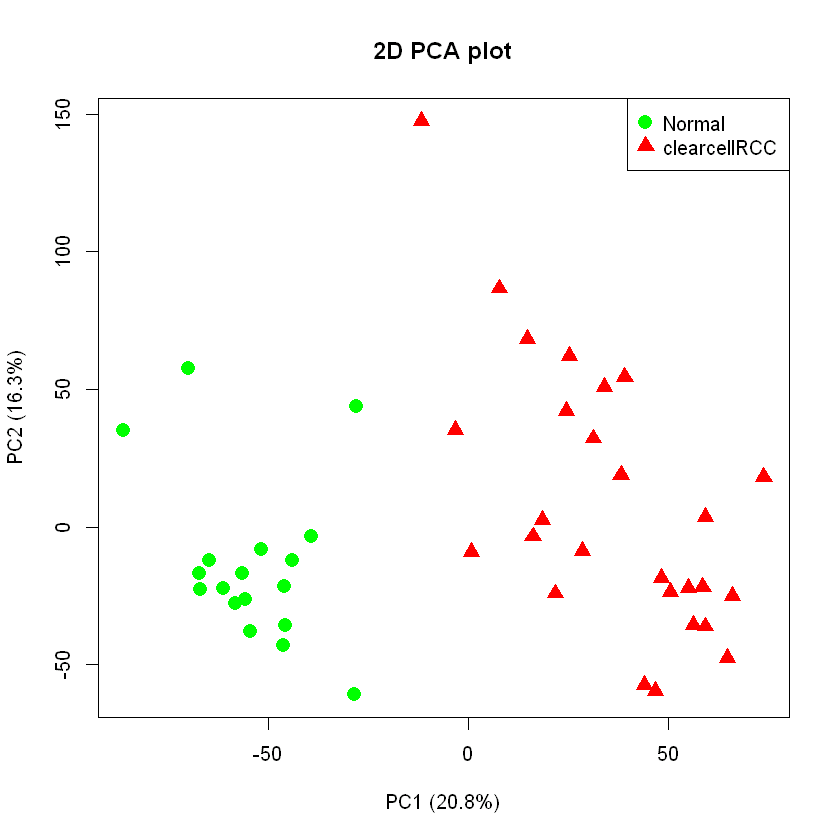

In [25]:
# Generate PCA scatter plot
pca <- prcomp(t(mat), scale=T)
a <- pca$sdev
pc1 <- a[1]^2/sum(a^2)
pc2 <- a[2]^2/sum(a^2)
# Set point symbols and colors for the normal and clearcellRCC groups
colors <- ifelse(class.labels=="normal", "green", "red")
symbols <- ifelse(class.labels=="normal", 16, 17)
# Generate PCA plot
plot(pca$x[,1:2], pch=symbols, cex=1.5, col=colors, main="2D PCA plot",
xlab=paste("PC1 (", round(100*pc1, 2), "%)", sep=""), 
ylab=paste("PC2 (", round(100*pc2, 2), "%)", sep=""))
legend("topright", legend=c("Normal","clearcellRCC"), col=c("green","red"), pch=c(16,17), pt.cex=1.5)

In [26]:
# Perform differential expression (DE) analysis using package limma
# Install package limma if it has not been installed yet
if (!requireNamespace("limma", quietly = TRUE)) BiocManager::install("limma")
library(limma)
group.labels <- ifelse(class.labels=="normal", 1, 2)
design.matrix <- model.matrix(~group.labels)
fit <- lmFit(mat, design=design.matrix)
fit <- eBayes(fit)
limma.results <- topTable(fit, n=nrow(fit))
head(limma.results)


Attaching package: 'limma'


The following object is masked from 'package:BiocGenerics':

    plotMA


Removing intercept from test coefficients



,logFC,AveExpr,t,P.Value,adj.P.Val,B
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
UMOD,-6.930412,8.065886,-66.81288,1.701394e-47,1.935846e-43,92.42272
KCNJ1,-4.634820,6.652169,-35.28659,5.524731e-35,3.143019e-31,68.54184
SLC12A1,-5.853837,5.761698,-32.28567,2.831582e-33,1.073925e-29,64.91988
KNG1,-6.024130,6.705970,-29.88983,8.416998e-32,2.394215e-28,61.75356
SERPINA5,-3.827242,7.152361,-26.18713,2.664713e-29,6.063820e-26,56.29690
FGF9,-3.061145,6.464414,-25.24722,1.288252e-28,2.442955e-25,54.78781


In [27]:
# Get indices of significant genes at the specified threshold
# In the limma results Table, column logFC is the log2 Fold-Change. Positive value
# indicates up-regulation in clearcellRCC compared to normal
# In the limma results Table, column adj.P.Val is the adjusted p-value using 
# Benjamini-Hochberg method which ensures control over False Discovery Rate (FDR)
logFC.thr <- 3
adj.pval.thr <- 1e-10
DE.ind <- which((limma.results$adj.P.Val < adj.pval.thr) & (abs(limma.results$logFC) > logFC.thr))

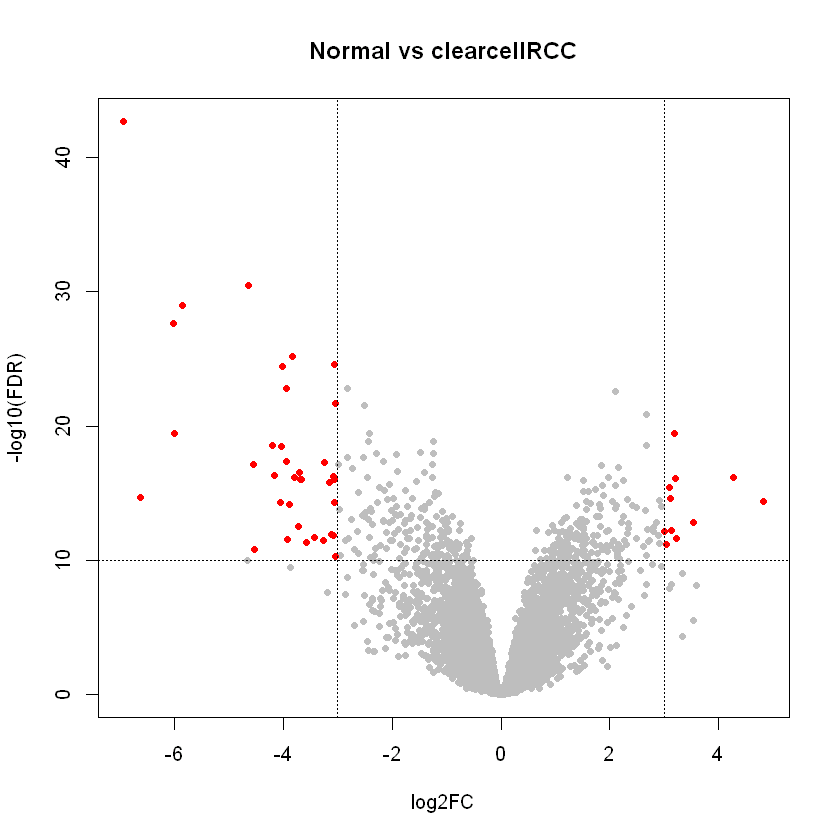

In [28]:
# Generate a volcano plot to visualize significant genes
colors <- rep("gray", nrow(limma.results))
# Highlight significant genes with red color
colors[DE.ind] <- "red"
plot(limma.results$logFC, -log10(limma.results$adj.P.Val), type="p", pch=16, col=colors,
cex=0.8, xlab="log2FC", ylab="-log10(FDR)", main="Normal vs clearcellRCC")
abline(v=c(-logFC.thr, logFC.thr), lty=3)
abline(h=-log10(adj.pval.thr), lty=3)

In [29]:
# Generate heatmap for the significant DE genes using package pheatmap
if(!requireNamespace("pheatmap", quietly=TRUE)) BiocManager::install("pheatmap")
library(pheatmap)
# Extract gene expressions for only significant genes
mydata <- mat[rownames(limma.results)[DE.ind],]
# Remove the exyension '.CEL' at the end of column names
colnames(mydata) <- gsub(x=colnames(mydata), pattern=".CEL", replacement="")

Warning message:
"package 'pheatmap' was built under R version 4.4.3"


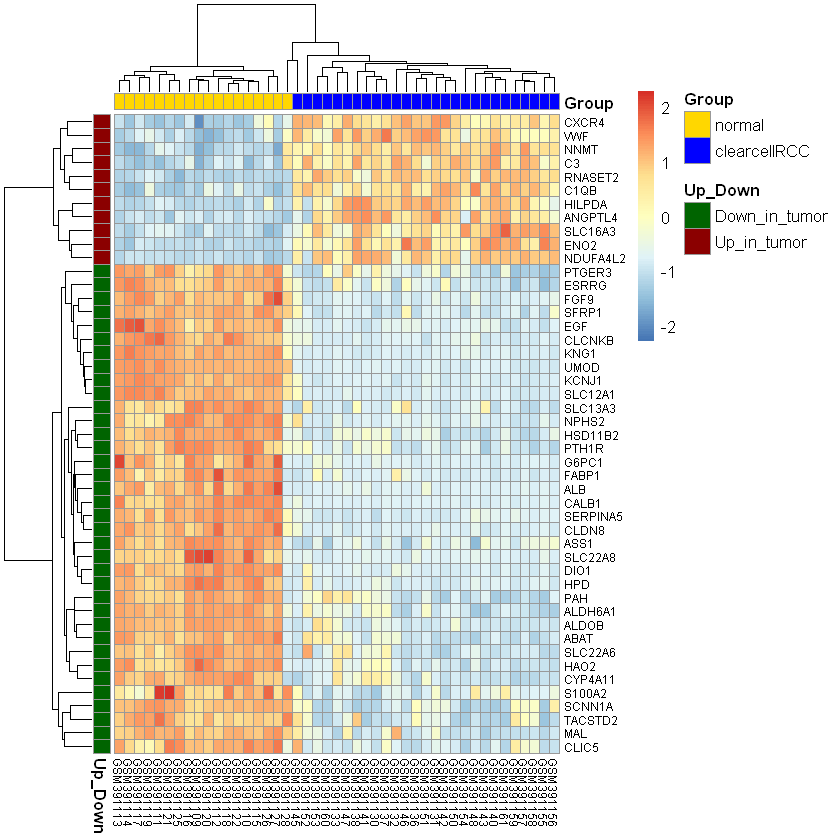

In [30]:
# Generate column annotations for the heatmap
annotation_col <- data.frame(Group=factor(class.labels))
rownames(annotation_col) = colnames(mydata)
# Generate row annotations for the heatmap
up_down <- limma.results[rownames(mydata),"logFC"]
up_down_col <- rep("Up_in_tumor", nrow(mydata))
up_down_col[up_down < 0] <- "Down_in_tumor"
annotation_row <- data.frame(Up_Down=factor(up_down_col))
rownames(annotation_row) <- rownames(mydata)
# Set annotation colors
ann_colors = list(Group=c(normal="gold", clearcellRCC="blue"), 
Up_Down=c(Down_in_tumor="darkgreen", Up_in_tumor="darkred"))

pheatmap(mydata, scale="row", annotation_col=annotation_col, annotation_row=annotation_row,
annotation_colors=ann_colors, show_rownames=T, show_colnames=T, fontsize_row=7, fontsize_col=7)

In [31]:
sessionInfo()

R version 4.4.2 (2024-10-31 ucrt)
Platform: x86_64-w64-mingw32/x64
Running under: Windows 11 x64 (build 22631)

Matrix products: default


locale:
[1] LC_COLLATE=English_United States.utf8 
[2] LC_CTYPE=English_United States.utf8   
[3] LC_MONETARY=English_United States.utf8
[4] LC_NUMERIC=C                          
[5] LC_TIME=English_United States.utf8    

time zone: America/Chicago
tzcode source: internal

attached base packages:
[1] stats4    stats     graphics  grDevices utils     datasets  methods  
[8] base     

other attached packages:
 [1] pheatmap_1.0.13       limma_3.62.2          hgu133a.db_3.13.0    
 [4] org.Hs.eg.db_3.20.0   AnnotationDbi_1.68.0  IRanges_2.40.1       
 [7] S4Vectors_0.44.0      genefilter_1.88.0     affyPLM_1.82.0       
[10] preprocessCore_1.68.0 gcrma_2.78.0          hgu133acdf_2.18.0    
[13] affy_1.84.0           R.utils_2.13.0        R.oo_1.27.0          
[16] R.methodsS3_1.8.2     GEOquery_2.74.0       Biobase_2.66.0       
[19] BiocGenerics_0.5